# Student 3 — Defect Detection
## Notebook 00: Dataset Preparation (aligned pipeline output)

### Why this notebook was rewritten

The first version of this notebook trained the detectors on `Clean_Dataset` — the raw boards
squashed to 512x512. But at integration time Student 3 does not receive that image. It receives:

```
raw board  ->  Student 1 preprocess  ->  Student 2 align  ->  detector
```

and Student 2's output is a **different picture**: colour-normalised and CLAHE-enhanced, with the
background cropped away, the board deskewed, and the aspect ratio preserved. A detector trained on
one distribution and shown the other finds nothing — which is exactly the symptom that was
observed. This is a classic **train/serve skew**.

The fix is to build the training set by running **the same pipeline the integration uses**, and to
carry the ground-truth boxes through the same geometry:

| Stage | Pixels | Boxes |
|---|---|---|
| Rotation (only for `PCB_DATASET/rotation`) | `rotate_bound_white_bg` | `rotation_matrix_bound` |
| Student 1 preprocessing | `preprocess_image` | unchanged (no geometry) |
| Student 2 alignment | `warpPerspective(H)` | `perspectiveTransform(H)` |

Both columns come from the **same** `image_pipeline.py` functions, so the training images cannot
drift away from the inference images again.

### What else changed

* **`ALIGN_TARGET` 640 -> 1280.** At 640 a ~70 px defect became ~15 px, too small to detect
  reliably. At 1280 it is ~30 px. This was the second half of the problem.
* **Full-resolution source.** The training set is built from `PCB_DATASET/images` (the originals
  the annotations belong to) and `PCB_DATASET/rotation` (the same boards rotated by a known angle),
  not from the 512 px `Clean_Dataset`, so no detail is thrown away before alignment.
* **Both variants of a board stay in the same split**, otherwise the rotated copy of a training
  board would leak into the test set and the reported accuracy would be inflated.

### 1. Imports and configuration

`image_pipeline.py` (project root) is the single source of truth for Student 1's preprocessing and
Student 2's alignment. Importing it here — rather than re-implementing either stage — is what
guarantees the training images match the integrated system.

In [1]:
import json, os, random, shutil, sys, time, warnings
import xml.etree.ElementTree as ET
from collections import Counter, defaultdict
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


def find_project_root(start: Path) -> Path:
    """Walk upwards until the folder holding image_pipeline.py / PCB_DATASET is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "image_pipeline.py").is_file() and (candidate / "PCB_DATASET").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the Image-Processing project root.")

PROJECT_ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT))
import image_pipeline as ip                      # Student 1 + Student 2, single source of truth

print("Project root :", PROJECT_ROOT)
print("OpenCV       :", cv2.__version__)
print("ALIGN_TARGET :", ip.ALIGN_TARGET, "px (longest side of Student 2's output)")

Project root : C:\Users\User\Image-Processing
OpenCV       : 5.0.0
ALIGN_TARGET : 1280 px (longest side of Student 2's output)


In [2]:
# ---------------------------------------------------------------- configuration
RANDOM_SEED  = 42
SPLIT_RATIO  = (0.70, 0.20, 0.10)
ALIGN_TARGET = ip.ALIGN_TARGET          # must match what inference uses - do not override lightly

USE_ROTATED  = True     # also build the aligned rotated copies (2x data, realistic residual skew)
REFRESH_S1_S2 = True    # rewrite Preprocessed_Dataset / Calibrated_Dataset from the live code

CLASS_NAMES = ["missing_hole", "mouse_bite", "open_circuit",
               "short", "spur", "spurious_copper"]
CLASS_TO_ID = {n: i for i, n in enumerate(CLASS_NAMES)}
CLASS_FOLDERS = ["Missing_hole", "Mouse_bite", "Open_circuit",
                 "Short", "Spur", "Spurious_copper"]

# ---------------------------------------------------------------- paths
IMAGES_DIR   = PROJECT_ROOT / "PCB_DATASET" / "images"      # full-res originals (match the XML)
ROTATION_DIR = PROJECT_ROOT / "PCB_DATASET" / "rotation"    # rotated copies + angle files
ANNOT_DIR    = PROJECT_ROOT / "Clean_Dataset" / "Annotations"

WORK_DIR    = PROJECT_ROOT / "Student3-Defect Detection"
DATASET_DIR = WORK_DIR / "dataset"
YOLO_DIR    = DATASET_DIR / "yolo"
COCO_DIR    = DATASET_DIR / "coco"
RESULTS_DIR = WORK_DIR / "results"
for d in (DATASET_DIR, YOLO_DIR, COCO_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print("Originals :", IMAGES_DIR)
print("Rotated   :", ROTATION_DIR)
print("Output    :", DATASET_DIR)

Originals : C:\Users\User\Image-Processing\PCB_DATASET\images
Rotated   : C:\Users\User\Image-Processing\PCB_DATASET\rotation
Output    : C:\Users\User\Image-Processing\Student3-Defect Detection\dataset


### 2. Index the source data

Every annotation in `Clean_Dataset/Annotations` refers to a **full-resolution original** in
`PCB_DATASET/images` — the `<size>` field in the XML matches that file exactly, so no coordinate
rescaling is needed here (unlike the old notebook, which had to undo the 512 px resize).

For each original the matching rotated copy and its angle are also recorded.

In [3]:
def parse_voc(xml_path: Path):
    """Return (declared_w, declared_h, labels, boxes_xyxy) straight from the XML."""
    root = ET.parse(xml_path).getroot()
    size = root.find("size")
    decl_w, decl_h = int(size.find("width").text), int(size.find("height").text)
    labels, boxes = [], []
    for obj in root.findall("object"):
        name = obj.find("name").text.strip().lower()
        if name not in CLASS_TO_ID:
            continue
        bb = obj.find("bndbox")
        boxes.append([float(bb.find(t).text) for t in ("xmin", "ymin", "xmax", "ymax")])
        labels.append(CLASS_TO_ID[name])
    return decl_w, decl_h, labels, boxes


boards, problems = [], []
for folder in CLASS_FOLDERS:
    angles_file = ROTATION_DIR / f"{folder}_angles.txt"
    angles = ip.read_rotation_angles(angles_file) if angles_file.is_file() else {}
    for img_path in sorted((IMAGES_DIR / folder).glob("*.jpg")):
        stem = img_path.stem
        xml_path = ANNOT_DIR / folder / f"{stem}.xml"
        if not xml_path.is_file():
            problems.append(f"{stem}: no annotation"); continue
        decl_w, decl_h, labels, boxes = parse_voc(xml_path)
        if not labels:
            problems.append(f"{stem}: no usable objects"); continue
        rot_path = ROTATION_DIR / f"{folder}_rotation" / f"{stem}.jpg"
        boards.append({
            "stem": stem, "folder": folder,
            "cls": CLASS_NAMES[labels[0]],
            "image": img_path, "xml": xml_path,
            "decl_size": (decl_w, decl_h),
            "labels": labels, "boxes": boxes,
            "rot_image": rot_path if rot_path.is_file() else None,
            "angle": angles.get(stem),
        })

n_rot = sum(1 for b in boards if b["rot_image"] is not None and b["angle"] is not None)
print(f"Boards indexed         : {len(boards)}")
print(f"With a rotated copy    : {n_rot}")
print(f"Total annotated boxes  : {sum(len(b['labels']) for b in boards)}")
print(f"Problems               : {len(problems)}", problems[:5])
assert boards, "No boards indexed - check PCB_DATASET/images and Clean_Dataset/Annotations."

Boards indexed         : 693
With a rotated copy    : 693
Total annotated boxes  : 2953
Problems               : 0 []


### 3. Check the XML sizes against the real files

If a `<size>` field disagreed with the image on disk, every box on that board would be wrong. This
check makes that impossible to miss. It also verifies that
`rotation_matrix_bound` reproduces the exact canvas of the rotated file — that is the proof that
the rotation is being replayed correctly rather than approximated.

In [4]:
bad_size, bad_rot = [], []
for b in boards:
    h, w = cv2.imread(str(b["image"]), cv2.IMREAD_REDUCED_COLOR_8).shape[:2]
    real = (w * 8, h * 8)                                # reduced read is 8x smaller
    if abs(real[0] - b["decl_size"][0]) > 8 or abs(real[1] - b["decl_size"][1]) > 8:
        bad_size.append((b["stem"], b["decl_size"], real))
    if b["rot_image"] is not None and b["angle"] is not None:
        _, nw, nh = ip.rotation_matrix_bound(*b["decl_size"], b["angle"])
        rh, rw = cv2.imread(str(b["rot_image"]), cv2.IMREAD_REDUCED_COLOR_8).shape[:2]
        if abs(nw - rw * 8) > 8 or abs(nh - rh * 8) > 8:
            bad_rot.append((b["stem"], (nw, nh), (rw * 8, rh * 8)))

print(f"XML size mismatches        : {len(bad_size)}", bad_size[:3])
print(f"Rotation canvas mismatches : {len(bad_rot)}", bad_rot[:3])
if not bad_size and not bad_rot:
    print("\nOK - annotations match the originals, and the rotation is reproduced exactly.")

XML size mismatches        : 0 []
Rotation canvas mismatches : 0 []

OK - annotations match the originals, and the rotation is reproduced exactly.


### 4. Split before processing

The split is decided on the **board**, not on the individual image, so a board's original and its
rotated copy always land in the same split. Splitting per image would put a board in train and a
near-identical rotated version of it in test, which inflates the reported accuracy.

In [5]:
rng = random.Random(RANDOM_SEED)
by_class = defaultdict(list)
for b in boards:
    by_class[b["cls"]].append(b)

split_of = {}
counts = {"train": 0, "val": 0, "test": 0}
for cls, items in sorted(by_class.items()):
    items = sorted(items, key=lambda x: x["stem"])
    rng.shuffle(items)
    n = len(items)
    n_train = int(round(n * SPLIT_RATIO[0]))
    n_val   = int(round(n * SPLIT_RATIO[1]))
    for i, b in enumerate(items):
        split = "train" if i < n_train else ("val" if i < n_train + n_val else "test")
        split_of[b["stem"]] = split
        counts[split] += 1

print(f"{'class':<18}{'train':>7}{'val':>7}{'test':>7}")
for cls in sorted(by_class):
    row = [sum(1 for b in by_class[cls] if split_of[b["stem"]] == s) for s in ("train", "val", "test")]
    print(f"{cls:<18}{row[0]:>7}{row[1]:>7}{row[2]:>7}")
print(f"{'BOARDS':<18}{counts['train']:>7}{counts['val']:>7}{counts['test']:>7}")
if USE_ROTATED:
    print(f"{'IMAGES (x2)':<18}{counts['train']*2:>7}{counts['val']*2:>7}{counts['test']*2:>7}"
          "   (original + rotated per board)")

class               train    val   test
missing_hole           80     23     12
mouse_bite             80     23     12
open_circuit           81     23     12
short                  81     23     12
spur                   80     23     12
spurious_copper        81     23     12
BOARDS                483    138     72
IMAGES (x2)           966    276    144   (original + rotated per board)


### 5. Build the aligned dataset

For every image: run **the exact inference pipeline**, compose the geometry, map the boxes, and
write the aligned image plus its YOLO label. `fallback=False` is used here on purpose — a board
that cannot be aligned is reported and skipped rather than silently entering the training set as an
unaligned frame. (At inference the fallback stays on, so a difficult board still gets inspected.)

> This loop reads ~1 400 full-resolution images and warps each one. Expect roughly **8–20 minutes**.

In [6]:
def to_yolo_line(label, box, w, h):
    x1, y1, x2, y2 = box
    return (f"{label} {(x1+x2)/2/w:.6f} {(y1+y2)/2/h:.6f} "
            f"{(x2-x1)/w:.6f} {(y2-y1)/h:.6f}")


for split in ("train", "val", "test"):
    for sub in ("images", "labels"):
        d = YOLO_DIR / sub / split
        d.mkdir(parents=True, exist_ok=True)
        for old in d.glob("*"):
            old.unlink()

if REFRESH_S1_S2:
    CALIB_DIR = PROJECT_ROOT / "Calibrated_Dataset"
    for folder in CLASS_FOLDERS:
        (CALIB_DIR / folder).mkdir(parents=True, exist_ok=True)

records, failures = [], []
t0 = time.perf_counter()
variants = ["original"] + (["rotated"] if USE_ROTATED else [])
total = len(boards) * len(variants)
done = 0

for b in boards:
    split = split_of[b["stem"]]
    for variant in variants:
        done += 1
        if variant == "rotated":
            if b["rot_image"] is None or b["angle"] is None:
                continue
            src_path = b["rot_image"]
            pre_matrix, _, _ = ip.rotation_matrix_bound(*b["decl_size"], b["angle"])
            name = f"{b['stem']}_rot"
        else:
            src_path = b["image"]
            pre_matrix = np.eye(3, dtype=np.float32)
            name = b["stem"]

        img = cv2.imread(str(src_path))
        aligned, H, size = ip.detection_input(img, target_longest=ALIGN_TARGET, fallback=False)
        if aligned is None:
            failures.append((name, "alignment failed")); continue

        out_w, out_h = size
        matrix = ip.compose(pre_matrix, H)               # original coords -> aligned coords
        boxes, keep = ip.transform_boxes(b["boxes"], matrix, out_w, out_h)
        if not boxes:
            failures.append((name, "all boxes fell outside the aligned board")); continue
        labels = [b["labels"][i] for i in keep]

        cv2.imwrite(str(YOLO_DIR / "images" / split / f"{name}.jpg"), aligned,
                    [cv2.IMWRITE_JPEG_QUALITY, 95])
        (YOLO_DIR / "labels" / split / f"{name}.txt").write_text(
            "\n".join(to_yolo_line(l, bx, out_w, out_h) for l, bx in zip(labels, boxes)),
            encoding="utf-8")

        if REFRESH_S1_S2 and variant == "original":
            cv2.imwrite(str(CALIB_DIR / b["folder"] / f"{b['stem']}.jpg"), aligned,
                        [cv2.IMWRITE_JPEG_QUALITY, 95])

        records.append({"name": name, "split": split, "cls": b["cls"], "variant": variant,
                        "width": out_w, "height": out_h, "labels": labels, "boxes": boxes,
                        "dropped": len(b["labels"]) - len(boxes)})

        if done % 100 == 0 or done == total:
            print(f"  {done:>5}/{total}  ({time.perf_counter()-t0:6.1f}s)  "
                  f"kept {len(records)}, failed {len(failures)}")

print(f"\nBuilt {len(records)} aligned images in {(time.perf_counter()-t0)/60:.1f} min")
print(f"Boxes kept   : {sum(len(r['labels']) for r in records)}")
print(f"Boxes dropped: {sum(r['dropped'] for r in records)} (outside the cropped board)")
print(f"Failures     : {len(failures)}", failures[:5])

    100/1386  (  16.4s)  kept 99, failed 1
    200/1386  (  31.0s)  kept 199, failed 1
    300/1386  (  46.5s)  kept 299, failed 1
    400/1386  (  62.6s)  kept 399, failed 1
    500/1386  (  76.7s)  kept 499, failed 1
    600/1386  (  93.8s)  kept 599, failed 1
    700/1386  ( 109.4s)  kept 699, failed 1
    800/1386  ( 126.4s)  kept 799, failed 1
    900/1386  ( 141.4s)  kept 899, failed 1
   1000/1386  ( 157.4s)  kept 999, failed 1
   1100/1386  ( 173.0s)  kept 1099, failed 1
   1200/1386  ( 187.8s)  kept 1199, failed 1
   1300/1386  ( 205.1s)  kept 1299, failed 1
   1386/1386  ( 219.2s)  kept 1385, failed 1

Built 1385 aligned images in 3.7 min
Boxes kept   : 5901
Boxes dropped: 0 (outside the cropped board)
Failures     : 1 [('05_missing_hole_09', 'alignment failed')]


### 6. Statistics

The defect size distribution is the number to watch. After alignment at 1280 px the boxes should
sit around 25–40 px — small, but well inside what a modern detector handles. If this histogram
drifts back down towards 15 px, `ALIGN_TARGET` has been lowered and the models will need retraining.

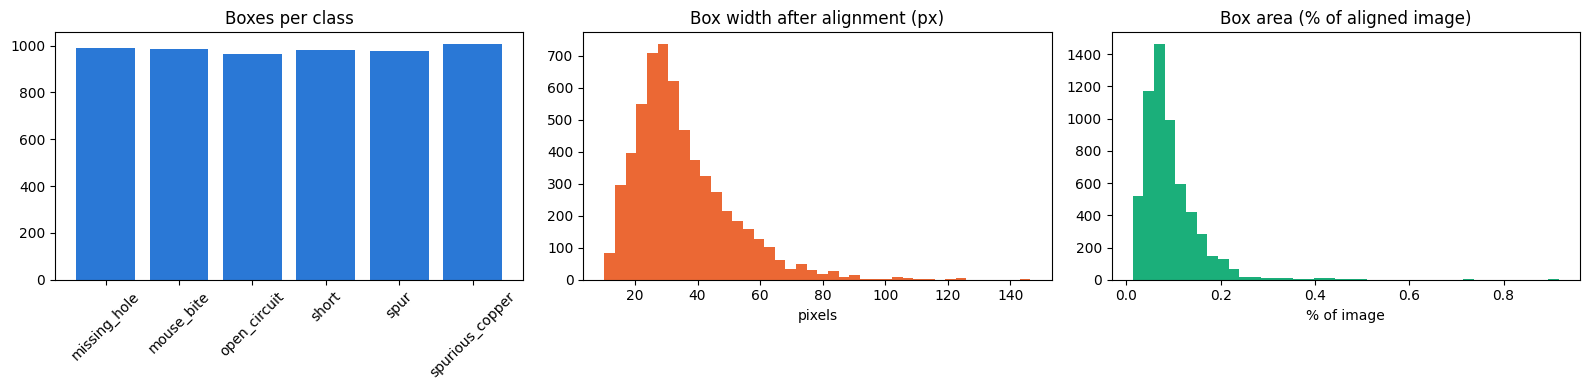

Boxes per class: {'missing_hole': 989, 'mouse_bite': 984, 'open_circuit': 964, 'short': 982, 'spur': 976, 'spurious_copper': 1006}
Median box: 31 x 31 px (0.078 % of the image)
Most common aligned sizes: [((1280, 1043), 179), ((1280, 655), 163), ((1280, 834), 79), ((1280, 984), 77)]


In [7]:
class_counts = Counter()
widths, heights, areas = [], [], []
for r in records:
    for lab, (x1, y1, x2, y2) in zip(r["labels"], r["boxes"]):
        class_counts[CLASS_NAMES[lab]] += 1
        widths.append(x2 - x1); heights.append(y2 - y1)
        areas.append((x2 - x1) * (y2 - y1) / (r["width"] * r["height"]) * 100)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].bar(list(class_counts), [class_counts[c] for c in class_counts], color="#2a78d6")
ax[0].set_title("Boxes per class"); ax[0].tick_params(axis="x", rotation=45)
ax[1].hist(widths, bins=40, color="#eb6834")
ax[1].set_title("Box width after alignment (px)"); ax[1].set_xlabel("pixels")
ax[2].hist(areas, bins=40, color="#1baf7a")
ax[2].set_title("Box area (% of aligned image)"); ax[2].set_xlabel("% of image")
plt.tight_layout(); plt.show()

sizes = Counter((r["width"], r["height"]) for r in records)
print("Boxes per class:", dict(class_counts))
print(f"Median box: {np.median(widths):.0f} x {np.median(heights):.0f} px "
      f"({np.median(areas):.3f} % of the image)")
print("Most common aligned sizes:", sizes.most_common(4))

### 7. Visual verification — read back from disk

The boxes are re-read from the saved YOLO label files and drawn on the saved aligned images. Both
variants of the same board are shown side by side: if the pair looks identical apart from a few
pixels of border, the rotation is being undone correctly and the annotations followed the pixels.

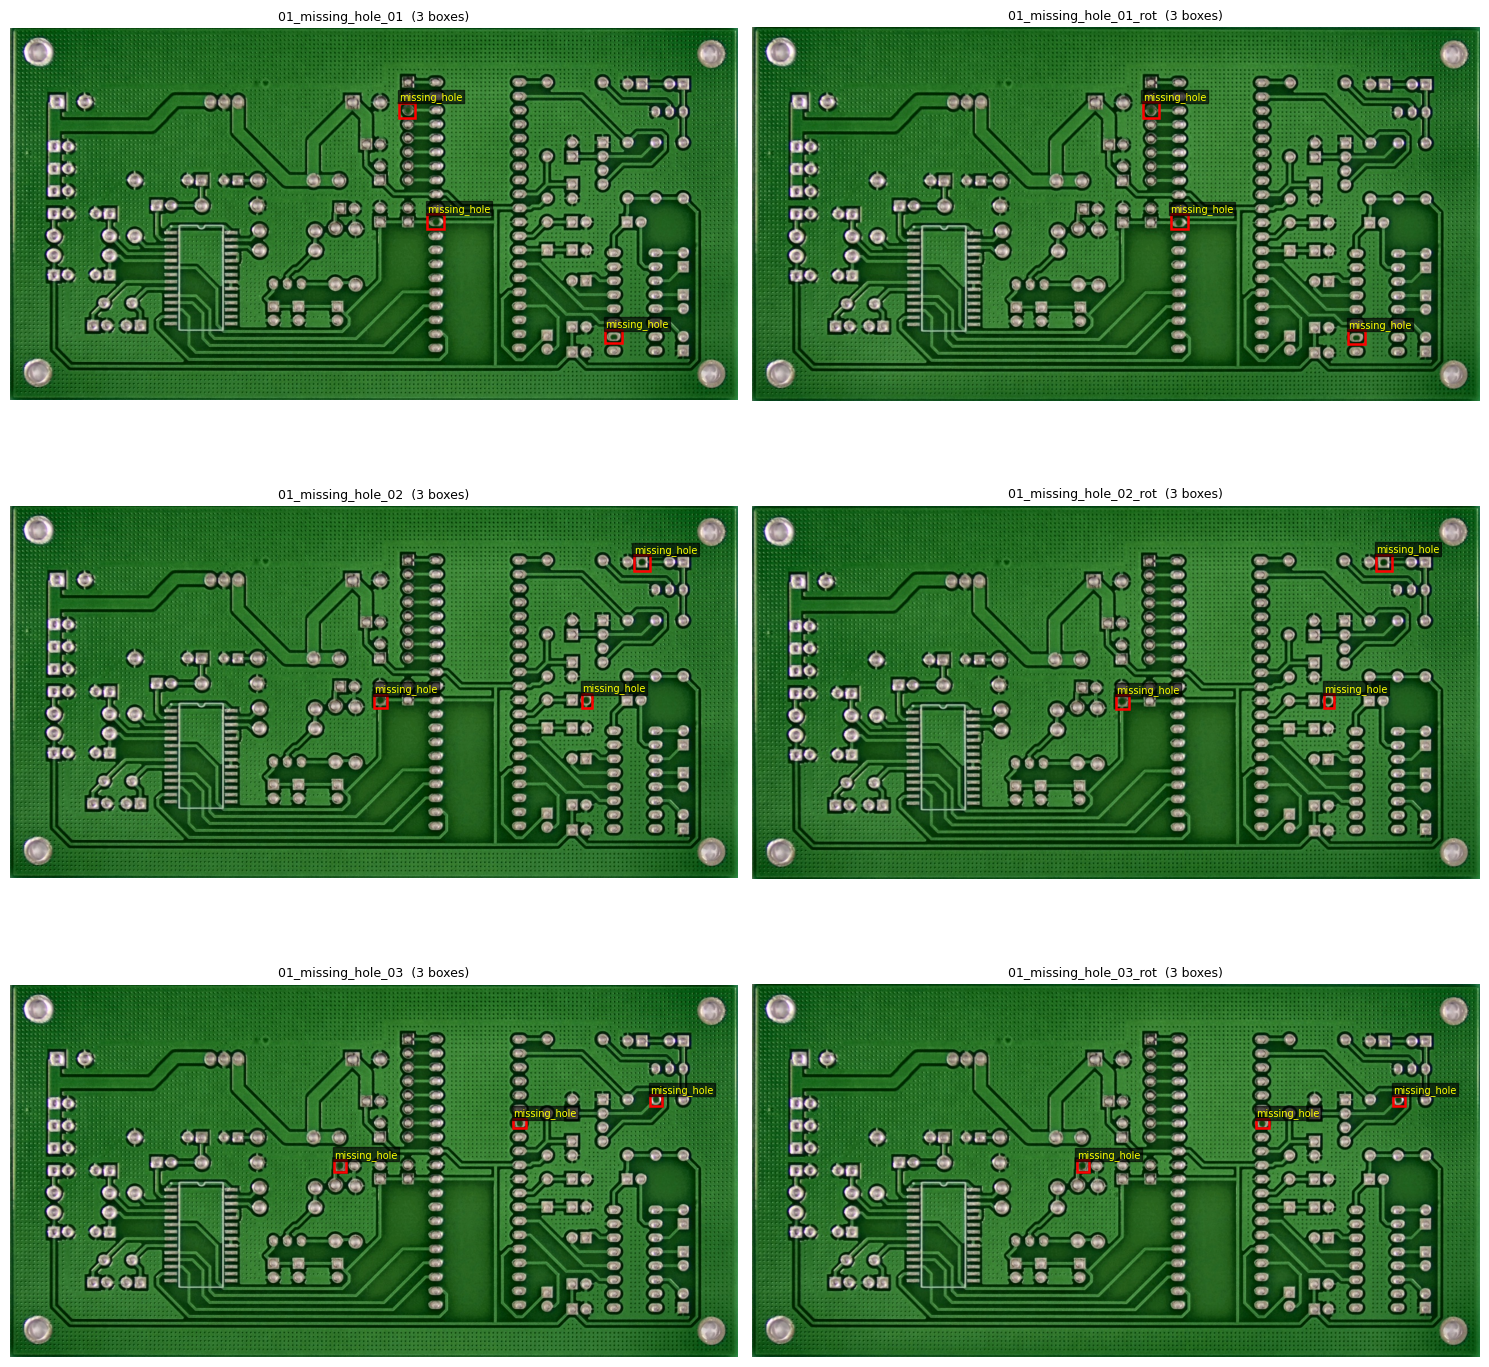

In [8]:
pairs = []
for r in records:
    if r["variant"] == "original" and any(x["name"] == r["name"] + "_rot" for x in records):
        pairs.append(r["name"])
    if len(pairs) == 3:
        break


def draw_from_disk(name):
    rec = next(r for r in records if r["name"] == name)
    img = cv2.cvtColor(cv2.imread(str(YOLO_DIR / "images" / rec["split"] / f"{name}.jpg")),
                       cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    out = []
    for line in (YOLO_DIR / "labels" / rec["split"] / f"{name}.txt").read_text().split("\n"):
        if not line.strip():
            continue
        c, cx, cy, bw, bh = line.split()
        cx, cy, bw, bh = float(cx)*w, float(cy)*h, float(bw)*w, float(bh)*h
        out.append((int(c), cx - bw/2, cy - bh/2, bw, bh))
    return img, out


fig, axes = plt.subplots(len(pairs), 2, figsize=(15, 5 * len(pairs)))
axes = np.atleast_2d(axes)
for row, stem in enumerate(pairs):
    for col, name in enumerate([stem, stem + "_rot"]):
        img, boxes = draw_from_disk(name)
        ax = axes[row][col]; ax.imshow(img)
        for c, x, y, bw, bh in boxes:
            ax.add_patch(plt.Rectangle((x, y), bw, bh, fill=False, edgecolor="red", linewidth=1.8))
            ax.text(x, max(y - 6, 10), CLASS_NAMES[c], color="yellow", fontsize=7,
                    bbox=dict(facecolor="black", alpha=.6, pad=1))
        ax.set_title(f"{name}  ({len(boxes)} boxes)", fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

### 8. Export — `data.yaml` for Ultralytics

In [9]:
data_yaml = YOLO_DIR / "data.yaml"
data_yaml.write_text(
    "# PCB defect detection on Student 2's ALIGNED output\n"
    "# generated by 00_data_preparation.ipynb - do not edit by hand\n"
    f"path: {YOLO_DIR.as_posix()}\n"
    "train: images/train\n"
    "val: images/val\n"
    "test: images/test\n"
    f"nc: {len(CLASS_NAMES)}\n"
    "names:\n" + "".join(f"  {i}: {n}\n" for i, n in enumerate(CLASS_NAMES)),
    encoding="utf-8")

for split in ("train", "val", "test"):
    n_img = len(list((YOLO_DIR / "images" / split).glob("*.jpg")))
    n_lbl = len(list((YOLO_DIR / "labels" / split).glob("*.txt")))
    n_box = sum(len(r["labels"]) for r in records if r["split"] == split)
    print(f"{split:<6} {n_img:4d} images / {n_lbl:4d} labels / {n_box:5d} boxes")
print("\n" + data_yaml.read_text())

train   965 images /  965 labels /  4097 boxes
val     276 images /  276 labels /  1196 boxes
test    144 images /  144 labels /   608 boxes

# PCB defect detection on Student 2's ALIGNED output
# generated by 00_data_preparation.ipynb - do not edit by hand
path: C:/Users/User/Image-Processing/Student3-Defect Detection/dataset/yolo
train: images/train
val: images/val
test: images/test
nc: 6
names:
  0: missing_hole
  1: mouse_bite
  2: open_circuit
  3: short
  4: spur
  5: spurious_copper



### 9. Export — COCO JSON for Faster R-CNN

Same images, torchvision's convention: absolute `[x, y, w, h]` boxes and category ids starting at 1
(id 0 is background).

In [10]:
categories = [{"id": i + 1, "name": n, "supercategory": "pcb_defect"}
              for i, n in enumerate(CLASS_NAMES)]

for split in ("train", "val", "test"):
    images, annotations, ann_id = [], [], 1
    for img_id, r in enumerate([x for x in records if x["split"] == split], start=1):
        images.append({"id": img_id, "file_name": f"{r['name']}.jpg",
                       "width": r["width"], "height": r["height"]})
        for lab, (x1, y1, x2, y2) in zip(r["labels"], r["boxes"]):
            annotations.append({"id": ann_id, "image_id": img_id, "category_id": lab + 1,
                                "bbox": [round(x1, 2), round(y1, 2),
                                         round(x2 - x1, 2), round(y2 - y1, 2)],
                                "area": round((x2 - x1) * (y2 - y1), 2), "iscrowd": 0})
            ann_id += 1
    out = COCO_DIR / f"instances_{split}.json"
    out.write_text(json.dumps({"info": {"description": "PCB defects on aligned boards"},
                               "images": images, "annotations": annotations,
                               "categories": categories}), encoding="utf-8")
    print(f"{out.name:<24} {len(images):4d} images, {len(annotations):5d} annotations")

instances_train.json      965 images,  4097 annotations
instances_val.json        276 images,  1196 annotations
instances_test.json       144 images,   608 annotations


### 10. Dataset manifest

`image_size` now records `ALIGN_TARGET`, so the training notebooks pick up the new resolution
automatically. `pipeline` records how the images were made — if any of it changes, the models must
be retrained.

In [11]:
info = {
    "source": "PCB_DATASET/images + PCB_DATASET/rotation via image_pipeline.detection_input()",
    "pipeline": {
        "student1": "preprocess_image (colour normalise -> Gaussian 5x5 -> CLAHE on L, clip 2.0, 8x8)",
        "student2": "align_image_with_matrix (Otsu board contour -> 4-point perspective warp)",
        "align_target": ALIGN_TARGET,
        "variants": variants,
    },
    "class_names": CLASS_NAMES,
    "num_classes": len(CLASS_NAMES),
    "image_size": ALIGN_TARGET,
    "random_seed": RANDOM_SEED,
    "split_ratio": list(SPLIT_RATIO),
    "counts": {s: sum(1 for r in records if r["split"] == s) for s in ("train", "val", "test")},
    "boxes": {s: sum(len(r["labels"]) for r in records if r["split"] == s)
              for s in ("train", "val", "test")},
    "boards": {s: sum(1 for b in boards if split_of[b["stem"]] == s) for s in ("train", "val", "test")},
    "failures": failures,
    "paths": {
        "yolo_root": YOLO_DIR.as_posix(),
        "yolo_yaml": (YOLO_DIR / "data.yaml").as_posix(),
        "coco_dir": COCO_DIR.as_posix(),
        "results_dir": RESULTS_DIR.as_posix(),
    },
    "files": {s: [r["name"] for r in records if r["split"] == s] for s in ("train", "val", "test")},
}
(DATASET_DIR / "dataset_info.json").write_text(json.dumps(info, indent=2), encoding="utf-8")
print(json.dumps({k: v for k, v in info.items() if k != "files"}, indent=2)[:1600])

{
  "source": "PCB_DATASET/images + PCB_DATASET/rotation via image_pipeline.detection_input()",
  "pipeline": {
    "student1": "preprocess_image (colour normalise -> Gaussian 5x5 -> CLAHE on L, clip 2.0, 8x8)",
    "student2": "align_image_with_matrix (Otsu board contour -> 4-point perspective warp)",
    "align_target": 1280,
    "variants": [
      "original",
      "rotated"
    ]
  },
  "class_names": [
    "missing_hole",
    "mouse_bite",
    "open_circuit",
    "short",
    "spur",
    "spurious_copper"
  ],
  "num_classes": 6,
  "image_size": 1280,
  "random_seed": 42,
  "split_ratio": [
    0.7,
    0.2,
    0.1
  ],
  "counts": {
    "train": 965,
    "val": 276,
    "test": 144
  },
  "boxes": {
    "train": 4097,
    "val": 1196,
    "test": 608
  },
  "boards": {
    "train": 483,
    "val": 138,
    "test": 72
  },
  "failures": [
    [
      "05_missing_hole_09",
      "alignment failed"
    ]
  ],
  "paths": {
    "yolo_root": "C:/Users/User/Image-Processing/Student3-D

### 11. Refresh Student 1's and Student 2's saved folders

`Preprocessed_Dataset` on disk was grayscale and `Calibrated_Dataset` was a 640x640 square, but the
live code produces a **colour** preprocessed image and an **aspect-preserving 1280 px** aligned
image. Those folders were stale outputs from earlier versions of the two notebooks. Section 5
already rewrote `Calibrated_Dataset` with the real aligned boards; this cell rewrites
`Preprocessed_Dataset` by running Student 1's live function over `Clean_Dataset`, so every saved
artefact in the project agrees with the code that produced it.

In [12]:
if REFRESH_S1_S2:
    CLEAN_DIR = PROJECT_ROOT / "Clean_Dataset"
    PRE_DIR   = PROJECT_ROOT / "Preprocessed_Dataset"
    n = 0
    for folder in CLASS_FOLDERS:
        (PRE_DIR / folder).mkdir(parents=True, exist_ok=True)
        for src in sorted((CLEAN_DIR / folder).glob("*.jpg")):
            out = ip.preprocess_image(cv2.imread(str(src)))
            if out is not None:
                cv2.imwrite(str(PRE_DIR / folder / src.name), out,
                            [cv2.IMWRITE_JPEG_QUALITY, 95])
                n += 1
    print(f"Preprocessed_Dataset : {n} colour images rewritten from Clean_Dataset")
    print(f"Calibrated_Dataset   : {sum(1 for r in records if r['variant']=='original')} "
          f"aligned boards rewritten at {ALIGN_TARGET} px (aspect preserved)")

    probe = cv2.imread(str(PRE_DIR / "Missing_hole" / "01_missing_hole_01.jpg"))
    print(f"\ncheck  Preprocessed_Dataset sample shape: {probe.shape}  "
          f"(3 channels = colour, matches preprocess_image)")
    probe = cv2.imread(str(PROJECT_ROOT / "Calibrated_Dataset" / "Missing_hole" / "01_missing_hole_01.jpg"))
    print(f"check  Calibrated_Dataset   sample shape: {probe.shape}  "
          f"(longest side = {ALIGN_TARGET}, aspect preserved)")
else:
    print("REFRESH_S1_S2 is False - the two folders were left untouched.")

Preprocessed_Dataset : 693 colour images rewritten from Clean_Dataset
Calibrated_Dataset   : 692 aligned boards rewritten at 1280 px (aspect preserved)

check  Preprocessed_Dataset sample shape: (512, 512, 3)  (3 channels = colour, matches preprocess_image)
check  Calibrated_Dataset   sample shape: (655, 1280, 3)  (longest side = 1280, aspect preserved)


### 12. Final check

Nothing here should print a warning. If it does, fix it before training — every minute spent
training on a broken dataset is wasted.

In [ ]:
problems = []
for split in ("train", "val", "test"):
    imgs = {p.stem for p in (YOLO_DIR / "images" / split).glob("*.jpg")}
    lbls = {p.stem for p in (YOLO_DIR / "labels" / split).glob("*.txt")}
    if imgs != lbls:
        problems.append(f"{split}: {len(imgs ^ lbls)} unpaired image/label files")
    for p in (YOLO_DIR / "labels" / split).glob("*.txt"):
        for line in p.read_text().split("\n"):
            if not line.strip():
                continue
            vals = line.split()
            if len(vals) != 5:
                problems.append(f"{p.name}: malformed line"); break
            if not (0 <= int(vals[0]) < len(CLASS_NAMES)):
                problems.append(f"{p.name}: class id out of range"); break
            if any(not (0.0 <= float(v) <= 1.0) for v in vals[1:]):
                problems.append(f"{p.name}: un-normalised coordinate"); break

# no board may appear in two different splits
board_split = defaultdict(set)
for r in records:
    board_split[r["name"].replace("_rot", "")].add(r["split"])
leaks = [b for b, s in board_split.items() if len(s) > 1]
if leaks:
    problems.append(f"{len(leaks)} boards leak across splits: {leaks[:3]}")

if problems:
    print("PROBLEMS FOUND:")
    for p in problems[:20]:
        print("  -", p)
else:
    print("All checks passed.")
    print(f"  {len(records)} aligned images, "
          f"{sum(len(r['labels']) for r in records)} boxes, no split leakage.")
    print("\nNext: 01_yolov10_training.ipynb")